<a href="https://colab.research.google.com/github/Bharanisiva77/AIML-workshop/blob/main/stock_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!pip install ta
from ta.momentum import RSIIndicator
from ta.trend import MACD, SMAIndicator
from ta.volatility import BollingerBands

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=5566d167573397d818eefcc1bbab63c0c255375902969681253906b50cfa180d
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [3]:
ticker = "AAPL"
start_date = "2015-01-01"
end_date = "2026-01-01"

df = yf.download(ticker, start=start_date, end=end_date)
df = df.dropna().copy()

/tmp/ipykernel_1241/634409897.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [6]:
df["Return_1"] = df[('Close', ticker)].pct_change(1)
df["Return_5"] = df[('Close', ticker)].pct_change(5)

df["SMA_10"] = SMAIndicator(close=df[('Close', ticker)], window=10).sma_indicator()
df["SMA_20"] = SMAIndicator(close=df[('Close', ticker)], window=20).sma_indicator()
df["RSI_14"] = RSIIndicator(close=df[('Close', ticker)], window=14).rsi()

macd = MACD(close=df[('Close', ticker)])
df["MACD"] = macd.macd()
df["MACD_Signal"] = macd.macd_signal()
df["MACD_Diff"] = macd.macd_diff()

bb = BollingerBands(close=df[('Close', ticker)], window=20, window_dev=2)
df["BB_High"] = bb.bollinger_hband()
df["BB_Low"] = bb.bollinger_lband()
df["BB_Mid"] = bb.bollinger_mavg()

df["Vol_Change"] = df[('Volume', ticker)].pct_change(1)

for lag in [1, 2, 3, 5, 10]:
    df[f"Close_Lag_{lag}"] = df[('Close', ticker)].shift(lag)
    df[f"Return_Lag_{lag}"] = df["Return_1"].shift(lag)

In [7]:
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
df = df.dropna().copy()

In [8]:
feature_cols = [
    "Return_1", "Return_5", "SMA_10", "SMA_20", "RSI_14",
    "MACD", "MACD_Signal", "MACD_Diff",
    "BB_High", "BB_Low", "BB_Mid",
    "Vol_Change",
    "Close_Lag_1", "Close_Lag_2", "Close_Lag_3", "Close_Lag_5", "Close_Lag_10",
    "Return_Lag_1", "Return_Lag_2", "Return_Lag_3", "Return_Lag_5", "Return_Lag_10"
]

X = df[feature_cols]
y = df["Target"]

In [9]:
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [10]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [11]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.44972577696526506

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.72      0.54       248
           1       0.49      0.22      0.31       299

    accuracy                           0.45       547
   macro avg       0.46      0.47      0.43       547
weighted avg       0.47      0.45      0.41       547


Confusion Matrix:
[[179  69]
 [232  67]]


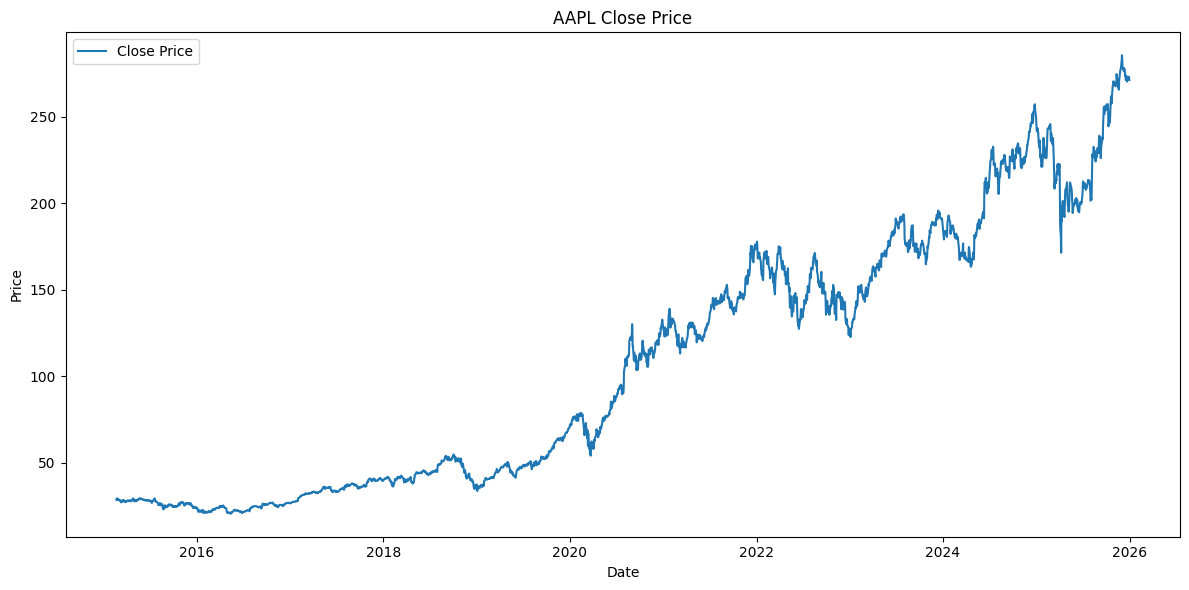

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Close"], label="Close Price")
plt.title(f"{ticker} Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()